# Scaling Monosemanticity

## 1. Review of SAE's

- Last week we studied Sparse Autoencoders, a dictionary learning technique pioneered by Anthropic for extracting monosemantic, interpretable features from neural network activations
- SAEs can be trained on any internal activation of a transformer — most commonly the residual stream or the output of an MLP sublayer at a given layer
- They consist of an encoder and decoder, each a single linear layer, with a ReLU activation between them:
$$z = \operatorname{ReLU}(W_{enc}(h - b_{dec}) + b_{enc}), \quad \hat{h} = W_{dec}z + b_{dec}$$
- The SAE learns an **overcomplete basis** ($d_{SAE} \gg d_{model}$) and is trained to reconstruct activations $h$ as $\hat{h}$. An L1 sparsity penalty on $z$ encourages most features to be zero for any given input, so each feature activates only for a narrow set of inputs (i.e., a specific concept or pattern — "feature" here means a learned dictionary element, not an input variable)
- The **column vectors of the decoder** $W_{dec}$ are the learned feature directions in activation space — these are the monosemantic, interpretable features. The encoder learns to detect when each feature is present


<img src="https://raw.githubusercontent.com/chloeli-15/ARENA_img/main/img/sae-diagram-2.png" width="900">

### Where we left off
- We introduced four properties we want robust monosemantic features to have and procedures for verifying them at small scale:
  1. **Specificity**: when a feature is active, the relevant concept is present in the input
  2. **Sensitivity**: when the relevant concept is present in the input, the feature is active
  3. **Causal**: intervening on the feature (amplifying or ablating it) leads to appropriate downstream behavior
  4. **Universality**: features learned by one SAE have "twins" in SAEs trained on different models
- We trained an SAE on a toy model and a one layer transformer trained on The Pile, but left open the question of whether this approach scales to frontier LLMs:
  1. Do larger LLMs represent features the same way, or does superposition change qualitatively with scale (and depth!)?
  2. "Towards Monosemanticity" required extensive human inspection to interpret features — how do we interpret hundreds of thousands of features autonomously?
  3. Will dictionary learning scale robustly with LLM size, or will we hit issues with the curse of dimensionality or training dynamics?

These are the questions addressed by Anthropic's follow-up paper, **"Scaling Monosemanticity"**, which we replicate in this notebook.

### This Week We Will
1. Briefly SAE's from last week 
2. Discuss Innovations in Scaling Monosemanticity that allowed Anthropic to scale from toy models to claude
- Gated SAE's, more sophisticated resampling techniques present in "Towards Monosemanticity" that we skipped last week
- Scaling laws for SAE's & Compute optimal training
- discovery that loss generally corresponds to how 'good' the SAE is (not always the case -- e.g. loss in GRPO is a horrible indicator of ground truth performance)
- substitution of L1 loss for L2 loss and other algorithmic optimizations
- LLM's for autonomous interpretability research 
3. Walk through a pretraining pipeline for SAE using SAELens and walk through the components
4. Verify the four properties mentioned above on SAE pretrained on a Pythia model, gaining familiarity with NDIF, NNSight, SAELens, and LogitLens

### 2a. Innovations in Autoencoders: Resampling

Resampling (which we briefly mentioned last week) solves the dead neuron problem by periodically resampling dead neurons (neurons which haven't activated on any sample in some resampling window period) -- manually changing their activations and allowing them to activate in a way that's useful for learning interpretable features. Specifically we


* Generate a batch of hidden data `h` from our SAE and compute its squared reconstruction loss `l2_squared`. It should have shape `(batch_size, n_inst)`. If the L2 loss for this instance `l2_squared[:, inst]` is zero everywhere, we can skip this instance.
* Find the dead latents for this instance (i.e. the instances `inst` and latent indices `d` where `frac_active_in_window[:, inst, d]` are all zero).
* For each of these, do the following:
    * Randomly sample a vector `v = h[x, inst, :]`, where `0 <= x < batch_size` is chosen according to the distribution with probabilities proportional to `l2_squared[:, inst]`.
    * Set the decoder weights `W_dec[inst, d, :]` to this new vector `v`, normalized.
    * Set the encoder weights `W_enc[inst, :, d]` to this new vector `v`, scaled to have norm `resample_scale * avg_W_enc_alive_norm` (where the term `avg_W_enc_alive_norm` is the mean norm of the encoder weights of alive neurons for that particular instance).
    * Set the encoder biases `b_enc[inst, d]` to zero.

In summary, the algorithm is: 
- Find all neurons which have never activated in the activations window
- Generate a probability distribution proportional to the reconstruction loss of each column `h[x, inst, :]` in our input activations 
- For each dead neuron, sample from this distribution. Set that neurons' weights equal to the activation at the index `x` in `h[x, inst, :]`

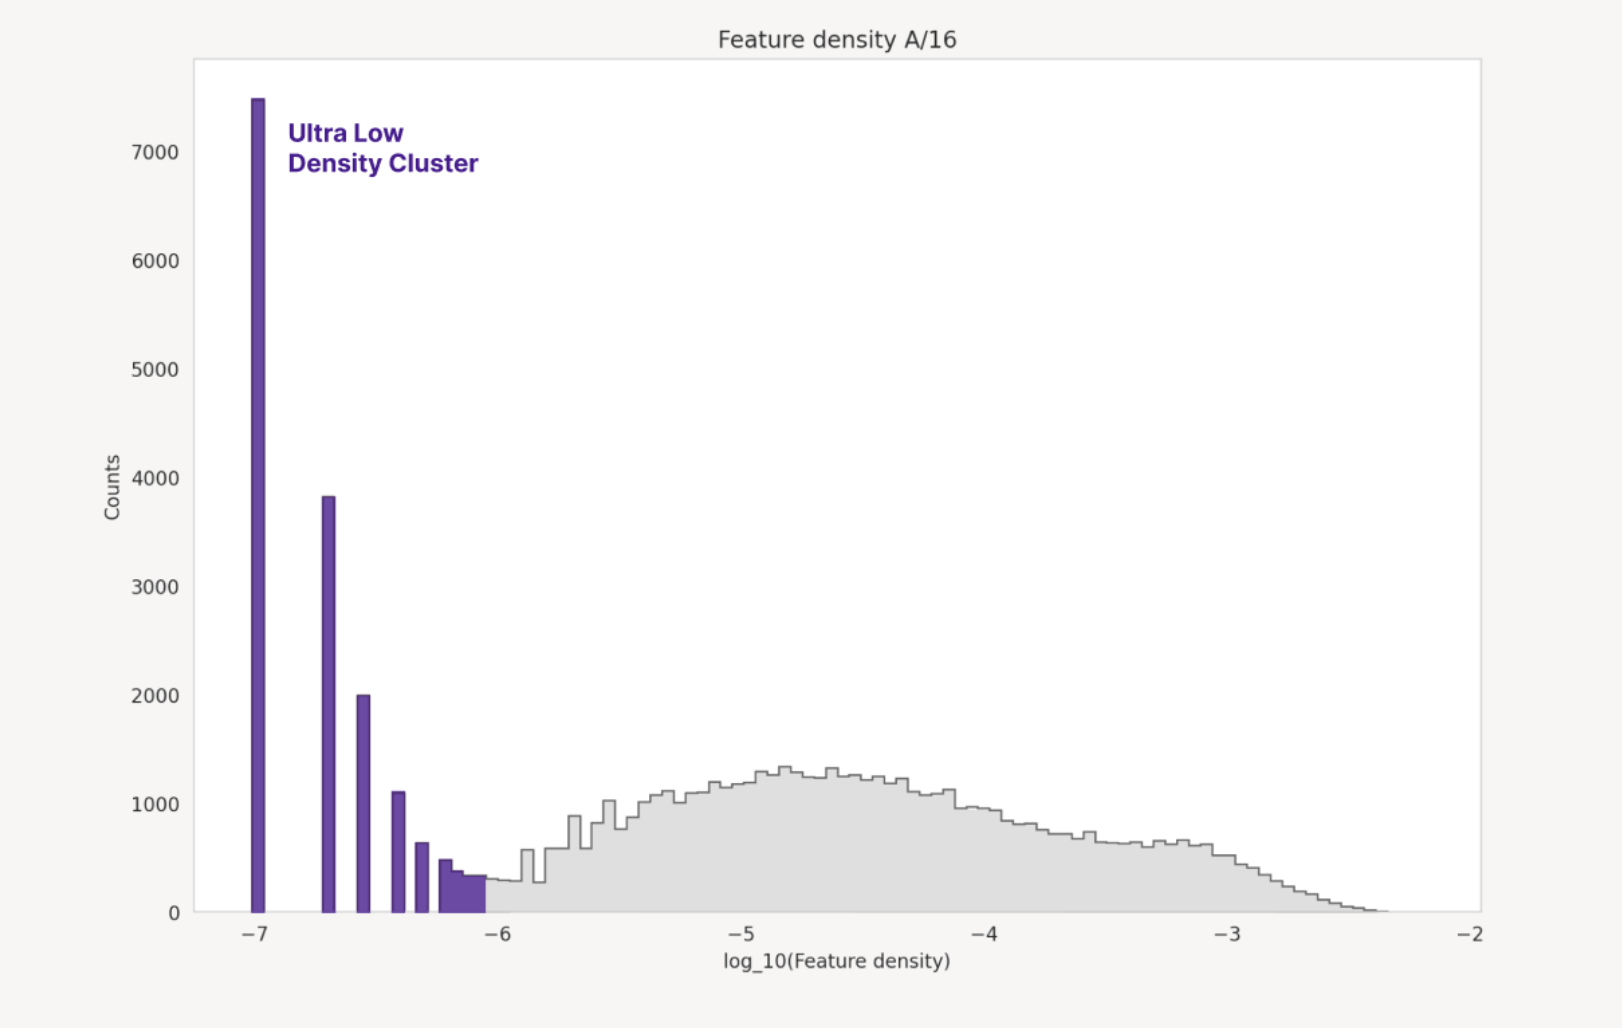

#### Code for More Advanced Resampling Method
(We'll re-run our autoencoder later after discussing the rest of the innovations introduced in Scaling Monosemanticity)

In [1]:
import gc
import itertools
import os
import random
from tqdm.auto import tqdm
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias
from nnsight import LanguageModel
from dictionary_learning.dictionary_learning.dictionary import AutoEncoder
import torch
from IPython.display import clear_output
from sae_lens import (
    LanguageModelSAERunnerConfig,
    LanguageModelSAETrainingRunner,
    StandardTrainingSAEConfig,
    LoggingConfig,
)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import torch.nn.functional as F
import circuitsvis as cv
import einops
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import torch as t
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import HTML, IFrame, display
from jaxtyping import Float, Int
from openai import OpenAI
from rich import print as rprint
from rich.table import Table
# from plotly_utils import imshow, line
import utils

Using device: cpu


In [2]:
import torch
import torch.nn as nn
from torch import Tensor
from jaxtyping import Float
from torch.distributions.categorical import Categorical

# insert this class alongside the ToySAE model we implemented last week
@torch.no_grad()
def resample_advanced( 
    self: nn.Module,
    frac_active_in_window: Float[Tensor, "window inst d_sae"],
    resample_scale: float,
    batch_size: int,
) -> None:

    """
    Resamples latents that have been dead for 'dead_feature_window' steps, according to `frac_active`.

    Resampling method is:
        - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
        - Randomly choose values of `h` with probability proportional to their reconstruction loss
        - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
        - Set b_enc to be zero, at each dead neuron

    Returns colors and titles (useful for creating the animation: resampled neurons appear in red).
    """
    print(f"using resample advanced")
    h = self.generate_batch(batch_size)
    l2_loss = self.forward(h)[0]["L_reconstruction"]

    for instance in range(self.cfg.n_inst):
        # Find the dead latents in this instance. If all latents are alive, continue
        is_dead = (frac_active_in_window[:, instance] < 1e-8).all(dim=0)
        dead_latents = t.nonzero(is_dead).squeeze(-1)
        n_dead = dead_latents.numel()
        if n_dead == 0:
            continue  # If we have no dead features, then we don't need to resample

        # Compute L2 loss for each element in the batch
        l2_loss_instance = l2_loss[:, instance]  # [batch_size]
        if l2_loss_instance.max() < 1e-6:
            continue  # If we have zero reconstruction loss, we don't need to resample

        # Draw `d_sae` samples from [0, 1, ..., batch_size-1], with probabilities proportional to
        # values of l2_loss
        distn = Categorical(probs=l2_loss_instance.pow(2) / l2_loss_instance.pow(2).sum())
        replacement_indices = distn.sample((n_dead,))  # type: ignore

        # Index into the batch of hidden activations to get our replacement values
        replacement_values = (h - self.b_dec)[replacement_indices, instance]  # [n_dead d_in]
        replacement_values_normalized = replacement_values / (
            replacement_values.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps
        )

        # Get the norm of alive neurons (or 1.0 if there are no alive neurons)
        W_enc_norm_alive_mean = (
            self.W_enc[instance, :, ~is_dead].norm(dim=0).mean().item() if (~is_dead).any() else 1.0
        )

        # Lastly, set the new weights & biases (W_dec is normalized, W_enc needs specific scaling,
        # b_enc is zero)
        self.W_dec.data[instance, dead_latents, :] = replacement_values_normalized
        self.W_enc.data[instance, :, dead_latents] = (
            replacement_values_normalized.T * W_enc_norm_alive_mean * resample_scale
        )
        self.b_enc.data[instance, dead_latents] = 0.0

This is the plot of neuron activation probabilities before and after implementing our more advanced resampling technique. 

#### Before: 

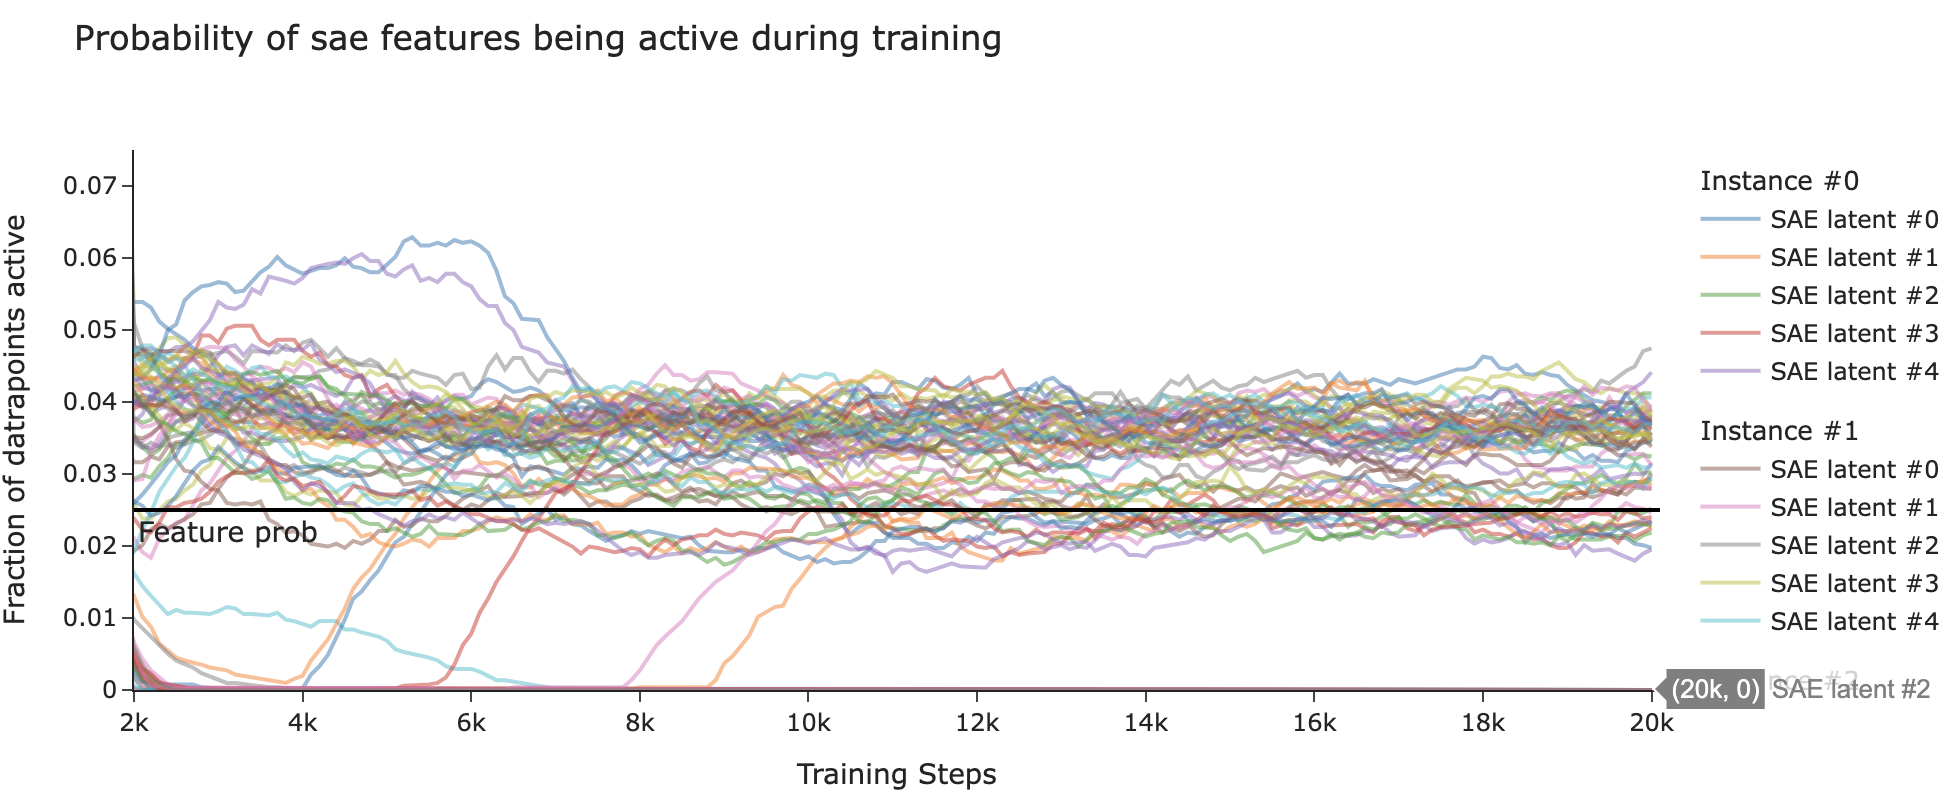

#### After: 

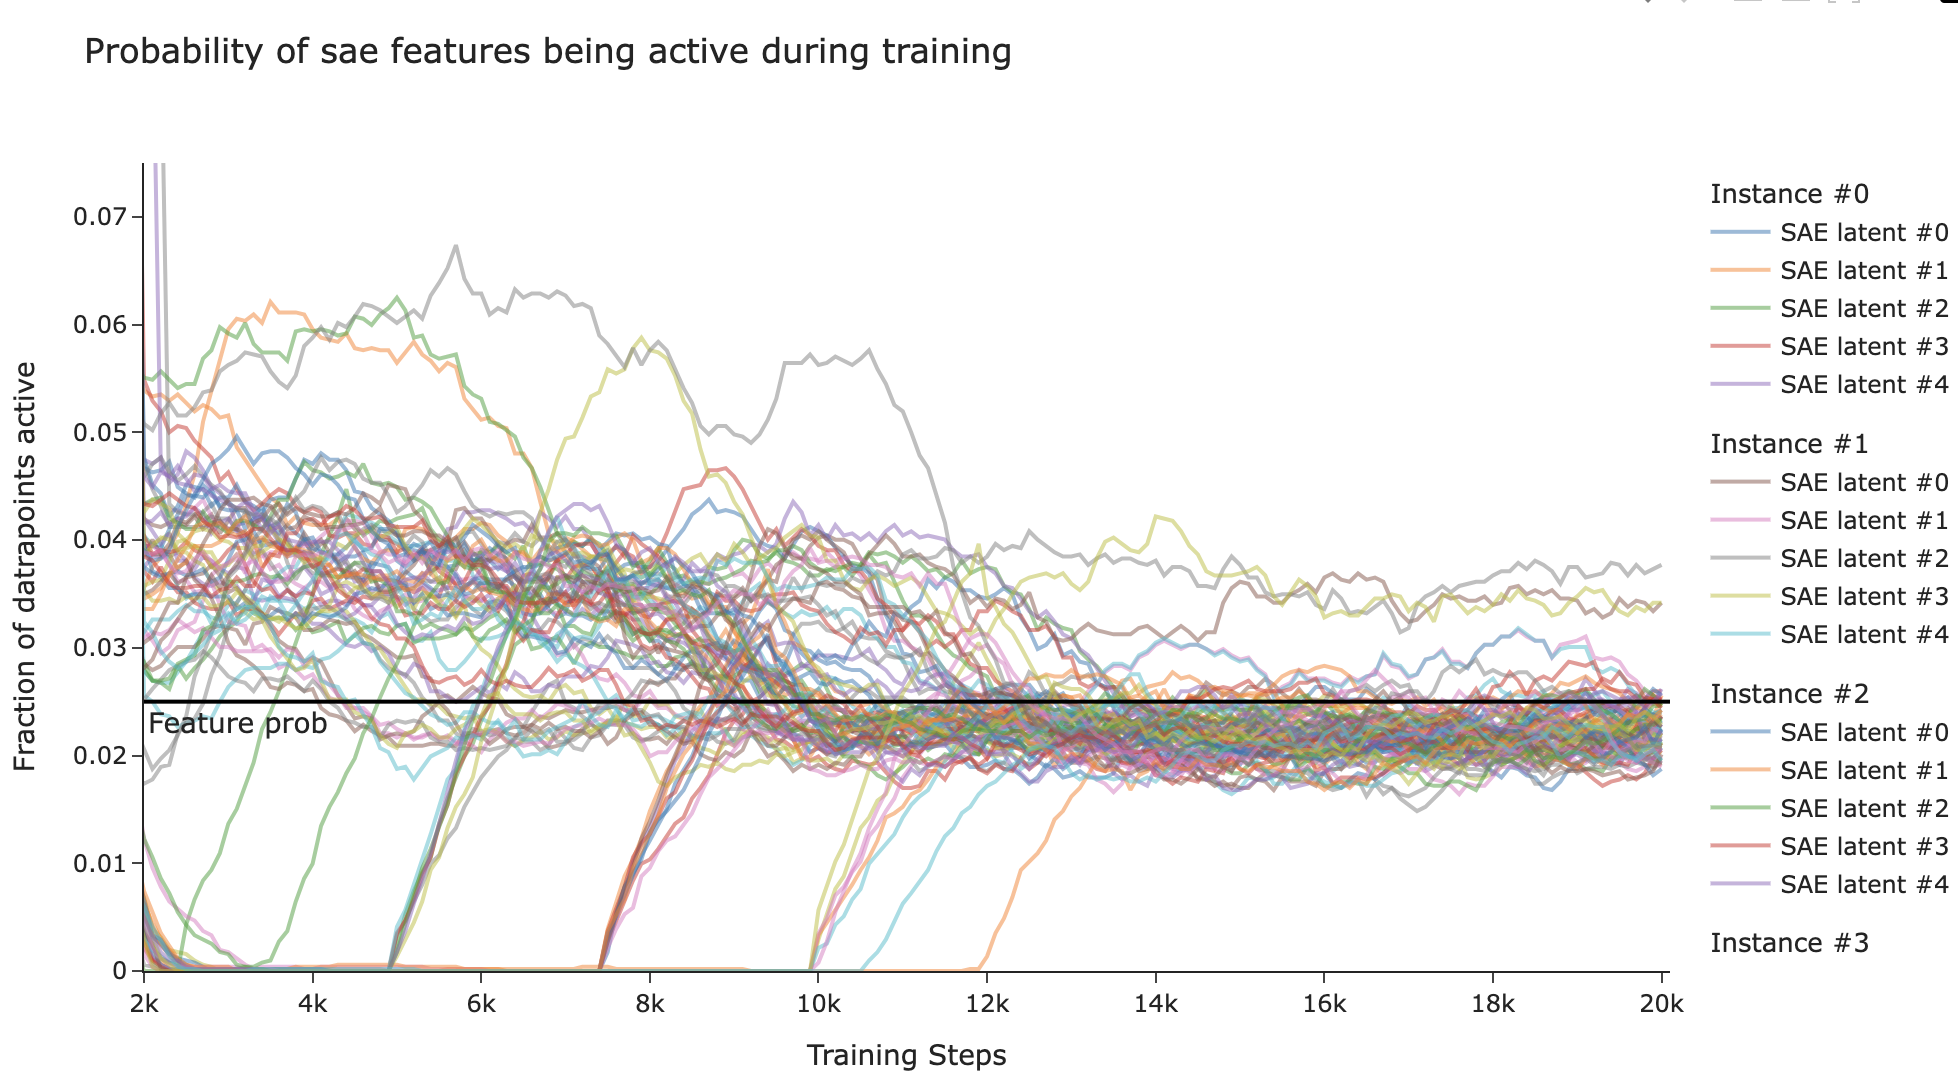

This might not look too different in the non-interactive PNG version, but if you look closely at the top image there is a large cluster of SAE latents on the x-axis with zero activations. These are dead neurons. There are NO dead neurons in the second image. This won't make a large difference in performance on our toy model, but in higher dimensional activation spaces it will impact performance considerably to resample in a targeted way!

### 2b. Innovations in Autoencoders: Gated SAE's 


### 2c. Innovations in Autoencoders: Algorithmic improvements



Let $n$ be the input and output dimension and $m$ be the autoencoder hidden layer dimension. Let $s$ be the size of the dataset. Given encoder weights $W_e \in \mathbb{R}^{m \times n}$, decoder weights $W_d \in \mathbb{R}^{n \times m}$, and biases $\mathbf{b}_e \in \mathbb{R}^m$, $\mathbf{b}_d \in \mathbb{R}^n$, the operations and loss function over a dataset $X \in \mathbb{R}^{s,n}$ are:

The operations and loss function over a dataset $X \in \mathbb{R}^{s,n}$ were originally:

$$\mathbf{f}(x) = \text{ReLU}(W_e \mathbf{x} + \mathbf{b}_e)$$

$$\hat{\mathbf{x}} = W_d \mathbf{f}(x) + \mathbf{b}_d$$

$$\mathcal{L} = \frac{1}{|X|} \sum_{\mathbf{x} \in X} ||\mathbf{x} - \hat{\mathbf{x}}||_2^2 + \lambda \sum_i |\mathbf{f}_i(x)|$$

The authors made the following changes: 
1. In Towards Monosemanticity the weights of the decoder $W_d$ are subject to a constrained L2 Norm:
$$||W_{d,i}||_2 \leq 1$$
Meaning the Euclidean Norm of each column vector in the decoder is normalized to $1$. The Authors remove this hard constraint 
$$||W_{d,i}||_2 \in \mathbb{R}^1$$
2. They penalize large norms in $W_d$ by elementwise multiplying the unconstrained L2 norm of the decoder weights with the activations of the encoder layer in the sparsity penalty. So originally the sparsity loss was simply the sum of the activations of the encoder layer:
$$\mathcal{L}_{\text{sparsity}} = \lambda \sum_i |\mathbf{f}_i(x)|$$
Now it becomes
$$\mathcal{L}_{\text{sparsity}} = \lambda \sum_i |\mathbf{f}_i(x)| \, ||W_{d,i}||_2 $$

Note what these changes do: rather than arbitrarily hardcoding a maximum norm on decoder columns:
- Penalizes decoder columns with large norms whose features activate frequently, pushing useless or redundant directions toward zero norm naturally through the loss.
- Allows the model to learn the natural scale of each feature — strongly activating features can have large decoder norms with moderate activations, rather than being forced to compensate for unit-norm decoder columns with artificially large activations that get heavily L1-penalized or by activating multiple decoder columns to scale activations.

So now the model equation and loss is: 

$$\mathbf{f}(x) = \text{ReLU}(W_e \mathbf{x} + \mathbf{b}_e)$$

$$\hat{\mathbf{x}} = W_d \mathbf{f}(x) + \mathbf{b}_d$$

$$\mathcal{L} = \frac{1}{|X|} \sum_{\mathbf{x} \in X} ||\mathbf{x} - \hat{\mathbf{x}}||_2^2 + \lambda \sum_i |\mathbf{f}_i(x)| \, ||W_{d,i}||_2$$


How would this change our ToySAE Code? Here is our original class



In [3]:
def linear_lr(step, steps):
    return 1 - (step / steps)


def constant_lr(*_):
    return 1.0


def cosine_decay_lr(step, steps):
    return np.cos(0.5 * np.pi * step / (steps - 1))


@dataclass
class ToyModelConfig:
    # We optimize n_inst models in a single training loop to let us sweep over sparsity or importance
    # curves efficiently. You should treat the number of instances `n_inst` like a batch dimension,
    # but one which is built into our training setup. Ignore the latter 3 arguments for now, they'll
    # return in later exercises.
    n_inst: int
    n_features: int = 5
    d_hidden: int = 2
    n_correlated_pairs: int = 0
    n_anticorrelated_pairs: int = 0
    feat_mag_distn: Literal["unif", "normal"] = "unif"


class ToyModel(nn.Module):
    W: Float[Tensor, "inst d_hidden feats"]
    b_final: Float[Tensor, "inst feats"]

    # Our linear map (for a single instance) is x -> ReLU(W.T @ W @ x + b_final)

    def __init__(
        self,
        cfg: ToyModelConfig,
        feature_probability: float | Tensor = 0.01,
        importance: float | Tensor = 1.0,
        device=device,
    ):
        super(ToyModel, self).__init__()
        self.cfg = cfg

        if isinstance(feature_probability, float):
            feature_probability = t.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to(
            (cfg.n_inst, cfg.n_features)
        )
        if isinstance(importance, float):
            importance = t.tensor(importance)
        self.importance = importance.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        self.W = nn.Parameter(
            nn.init.xavier_normal_(t.empty((cfg.n_inst, cfg.d_hidden, cfg.n_features)))
        )
        self.b_final = nn.Parameter(t.zeros((cfg.n_inst, cfg.n_features)))
        self.device = device
        self.to(device)

    def forward(
        self,
        features: Float[Tensor, "... inst feats"],
    ) -> Float[Tensor, "... inst feats"]:
        """
        Performs a single forward pass. For a single instance, this is given by:
            x -> ReLU(W.T @ W @ x + b_final)
        """

        wtw = einops.einsum(self.W, self.W, 'i h f1, i h f2 -> i f1 f2')
        a = einops.einsum(wtw, features, 'i f1 f2 , ... i f2 -> ... i f1')
        out = F.relu(a + self.b_final)

        # wx = einops.einsum(self.W, features, 'i h f, ... i f -> ... i h')
        # a = einops.einsum(self.W, wx, 'i h f, ... i h -> ... i f')
        # out = F.relu(a + self.b_final)
        return out



    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst feats"]:
        """
        Generates a batch of data of shape (batch_size, n_instances, n_features).
        """
        # generate random feature values
        features = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device)
        # generate seed values
        probs = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device) # why don't we need a random seed for each index
        
        # where probs <= feature_probability we set the feature to active, else 0
        batch = torch.where(probs <= self.feature_probability, input=features, other=0.0)


        return batch
    def calculate_loss(
        self,
        out: Float[Tensor, "batch inst feats"],
        batch: Float[Tensor, "batch inst feats"],
    ) -> Float[Tensor, ""]:
        """
        Calculates the loss for a given batch (as a scalar tensor), using this loss described in the
        Toy Models of Superposition paper:

            https://transformer-circuits.pub/2022/toy_model/index.html#demonstrating-setup-loss

        Note, `self.importance` is guaranteed to broadcast with the shape of `out` and `batch`.
        """
        # You'll fill this in later
        mean_residual = einops.reduce(self.importance * ((out - batch) ** 2), 'b i f ->i', reduction='mean')
        return mean_residual.sum()

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 5_000,
        log_freq: int = 50,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
    ):
        """
        Optimizes the model using the given hyperparameters.
        """
        optimizer = t.optim.Adam(self.parameters(), lr=lr)

        progress_bar = tqdm(range(steps))

        for step in progress_bar:
            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Optimize
            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

            # Display progress bar
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(loss=loss.item() / self.cfg.n_inst, lr=step_lr)

cfg = ToyModelConfig(n_inst=8, n_features=5, d_hidden=2)

# importance varies within features for each instance
importance = 0.9 ** t.arange(cfg.n_features)

# sparsity is the same for all features in a given instance, but varies over instances
feature_probability = 50 ** -t.linspace(0, 1, cfg.n_inst)
model = ToyModel(
    cfg=cfg,
    device=device,
    importance=importance[None, :],
    feature_probability=feature_probability[:, None],
)
model.optimize()


  0%|          | 0/5000 [00:00<?, ?it/s]

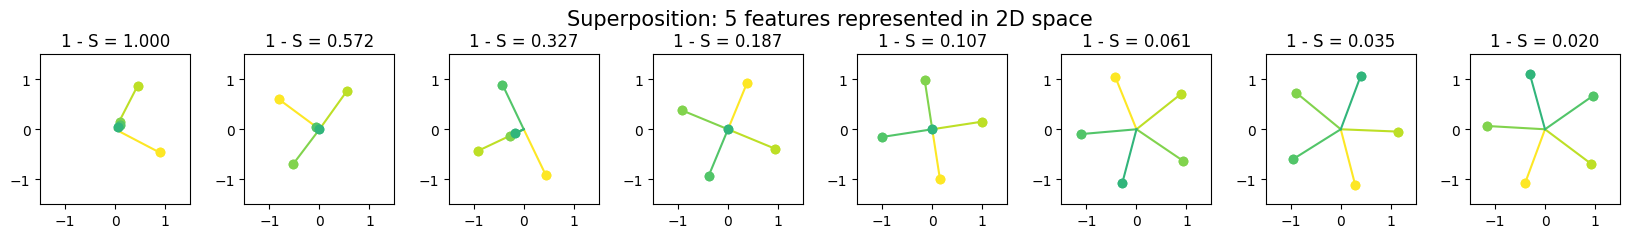

In [4]:
utils.plot_features_in_2d(
    model.W,
    colors=model.importance,
    title=f"Superposition: {cfg.n_features} features represented in 2D space",
    subplot_titles=[f"1 - S = {i:.3f}" for i in feature_probability.squeeze()],
)

# why does this appear to be learning all features at zero sparsity? is my penalty lower

In [5]:
@dataclass
class ToySAEConfig:
    n_inst: int
    d_in: int
    d_sae: int
    sparsity_coeff: float = 0.2
    weight_normalize_eps: float = 1e-8
    tied_weights: bool = False
    ste_epsilon: float = 0.01


class ToySAE(nn.Module):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]

    def __init__(self, cfg: ToySAEConfig, model: ToyModel) -> None:
        super(ToySAE, self).__init__()

        assert cfg.d_in == model.cfg.d_hidden, "Model's hidden dim doesn't match SAE input dim"
        self.cfg = cfg
        self.model = model.requires_grad_(False)
        self.model.W.data[1:] = self.model.W.data[0]
        self.model.b_final.data[1:] = self.model.b_final.data[0]

        self.W_enc = nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_in, cfg.d_sae))))
        self._W_dec = (
            None
            if self.cfg.tied_weights
            else nn.Parameter(nn.init.kaiming_uniform_(t.empty((cfg.n_inst, cfg.d_sae, cfg.d_in))))
        )
        self.b_enc = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_sae))
        self.b_dec = nn.Parameter(t.zeros(cfg.n_inst, cfg.d_in))

        self.to(device)

    @property
    def W_dec(self) -> Float[Tensor, "inst d_sae d_in"]:
        return self._W_dec if self._W_dec is not None else self.W_enc.transpose(-1, -2)


    # notice how this is normalized right now. We remove this below
    @property
    def W_dec_normalized(self) -> Float[Tensor, "inst d_sae d_in"]:
        """Returns decoder weights, normalized over the autoencoder input dimension."""
        return self.W_dec / (self.W_dec.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps)

    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst d_in"]:
        """
        Generates a batch of hidden activations from our model.
        """
        batch = self.model.generate_batch(batch_size) 
        return einops.einsum(batch, self.model.W, 'b i f, i h f -> b i h')


    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Forward pass on the autoencoder.

        Args:
            h: hidden layer activations of model

        Returns:
            loss_dict:       dict of different loss terms, each having shape (batch_size, n_inst)
            loss:            total loss (i.e. sum over terms of loss dict), same shape as loss values
            acts_post:       autoencoder latent activations, after applying ReLU
            h_reconstructed: reconstructed autoencoder input
        """

        raise NotImplementedError()


    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 10_000,
        log_freq: int = 100,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
        resample_method: Literal["simple", "advanced", None] = None,
        resample_freq: int = 2500,
        resample_window: int = 500,
        resample_scale: float = 0.5,
        hidden_sample_size: int = 256,
    ) -> list[dict[str, Any]]:
        """
        Optimizes the autoencoder using the given hyperparameters.

        Args:
            model:              we reconstruct features from model's hidden activations
            batch_size:         size of batches we pass through model & train autoencoder on
            steps:              number of optimization steps
            log_freq:           number of optimization steps between logging
            lr:                 learning rate
            lr_scale:           learning rate scaling function
            resample_method:    method for resampling dead latents
            resample_freq:      number of optimization steps between resampling dead latents
            resample_window:    number of steps needed for us to classify a neuron as dead
            resample_scale:     scale factor for resampled neurons
            hidden_sample_size: size of hidden value sample we add to the logs (for visualization)

        Returns:
            data_log:           dictionary containing data we'll use for visualization
        """
        assert resample_window <= resample_freq

        optimizer = t.optim.Adam(self.parameters(), lr=lr)  # betas=(0.0, 0.999)
        frac_active_list = []
        progress_bar = tqdm(range(steps))

        # Create lists of dicts to store data we'll eventually be plotting
        data_log = []

        for step in progress_bar:
            # Resample dead latents
            if (resample_method is not None) and ((step + 1) % resample_freq == 0):
                frac_active_in_window = t.stack(frac_active_list[-resample_window:], dim=0)
                if resample_method == "simple":
                    self.resample_simple(frac_active_in_window, resample_scale)
                elif resample_method == "advanced":
                    self.resample_advanced(frac_active_in_window, resample_scale, batch_size)

            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Get a batch of hidden activations from the model
            with t.inference_mode():
                h = self.generate_batch(batch_size)

            # Optimize
            loss_dict, loss, acts, _ = self.forward(h)
            loss.mean(0).sum().backward()
            optimizer.step()
            optimizer.zero_grad()

            # Normalize decoder weights by modifying them directly (if not using tied weights)
            if not self.cfg.tied_weights:
                self.W_dec.data = self.W_dec_normalized.data

            # Calculate the mean sparsities over batch dim for each feature
            frac_active = (acts.abs() > 1e-8).float().mean(0)
            frac_active_list.append(frac_active)

            # Display progress bar, and log a bunch of values for creating plots / animations
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(
                    lr=step_lr,
                    loss=loss.mean(0).sum().item(),
                    frac_active=frac_active.mean().item(),
                    **{k: v.mean(0).sum().item() for k, v in loss_dict.items()},  # type: ignore
                )
                with t.inference_mode():
                    loss_dict, loss, acts, h_r = self.forward(
                        h := self.generate_batch(hidden_sample_size)
                    )
                data_log.append(
                    {
                        "steps": step,
                        "frac_active": (acts.abs() > 1e-8).float().mean(0).detach().cpu(),
                        "loss": loss.detach().cpu(),
                        "h": h.detach().cpu(),
                        "h_r": h_r.detach().cpu(),
                        **{name: param.detach().cpu() for name, param in self.named_parameters()},
                        **{name: loss_term.detach().cpu() for name, loss_term in loss_dict.items()},
                    }
                )

        return data_log

    @t.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        """
        Resamples dead latents, by modifying the model's weights and biases inplace.

        Resampling method is:
            - For each dead neuron, generate a random vector of size (d_in,), and normalize these vecs
            - Set new values of W_dec and W_enc to be these normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

    @t.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        """
        Resamples latents that have been dead for `dead_feature_window` steps, according to `frac_active`.

        Resampling method is:
            - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
            - Randomly choose values of `h` with probability proportional to their reconstruction loss
            - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

In [6]:
@property
def W_dec_normalized(self: ToySAE) -> Float[Tensor, "inst d_sae d_in"]:
    """Returns decoder weights, normalized over the autoencoder input dimension."""
    return self.W_dec # no constrained normalization occurring


ToySAE.W_dec_normalized = W_dec_normalized
ToySAE.resample_advanced = resample_advanced # let's also add our new resampling method in

Meanwhile we change our loss function to this:

In [13]:

def forward(
        self: ToySAE, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Forward pass on the autoencoder.

        Args:
            h: hidden layer activations of model

        Returns:
            loss_dict:       dict of different loss terms, each having shape (batch_size, n_inst)
            loss:            total loss (i.e. sum over terms of loss dict), same shape as loss values
            acts_post:       autoencoder latent activations, after applying ReLU
            h_reconstructed: reconstructed autoencoder input
        """

        # z = relu(W_enc(h - b_dec) + b_enc)
        centered = h - self.b_dec
        proj = einops.einsum(self.W_enc, centered, 'inst d_in d_sae ,batch inst d_in -> batch inst d_sae') + self.b_enc
        acts_post = F.relu(proj)

        # h' = (W_dec * z) + b_dec
        h_reconstructed = einops.einsum(self.W_dec_normalized, acts_post, 'inst d_sae d_in, batch inst d_sae -> batch inst d_in') + self.b_dec

        # compute reconstruction loss: 
        L_reconstruction = einops.reduce((h - h_reconstructed)**2,'batch inst d_in -> batch inst', reduction='mean')

        # compute sparsity loss with modifications described in scaling monosemanticity
        sum_of_squares = einops.reduce(self.W_dec_normalized**2, 'inst d_sae d_in -> inst d_sae', reduction='sum') # get sum of squares
        l2_norm = torch.sqrt(sum_of_squares) # l2 norm = sqrt(a^2 + b^2 .... n^2)

        loss_term = acts_post * l2_norm * self.cfg.sparsity_coeff # (batch, inst, d_sae) * (inst, d_sae). this will automatically broadcast
        
        # loss_term = acts_post * self.W_dec_normalized.norm(dim=-1, keepdim=True) # now we're using the unconstrained L2 norm as a penalty to multiply our activations by
        L_sparsity = einops.reduce(loss_term, 'batch inst d_sae -> batch inst', reduction='sum')

        # form return parameters
        loss_dict = {
            "L_reconstruction": L_reconstruction,
            "L_sparsity": L_sparsity
        }
        loss = L_sparsity + L_reconstruction
        return loss_dict, loss, acts_post, h_reconstructed
ToySAE.forward = forward

In [14]:
# train toy model 
d_hidden = d_in = 2
n_features = d_sae = 5
n_inst = 16

# Create a toy model, and train it to convergence
cfg = ToyModelConfig(n_inst=n_inst, n_features=n_features, d_hidden=d_hidden)
model = ToyModel(cfg=cfg, device=device, feature_probability=0.025)
model.optimize()


  0%|          | 0/5000 [00:00<?, ?it/s]

In [15]:
# train SAE
sae = ToySAE(cfg=ToySAEConfig(n_inst=n_inst, d_in=d_in, d_sae=d_sae), model=model)

# h = sae.generate_batch(512)
# loss_dict, loss, acts_post, h_reconstructed = sae.forward(h)
data_log = sae.optimize(steps=20_000, resample_method="advanced")

  0%|          | 0/20000 [00:00<?, ?it/s]

using resample advanced
using resample advanced
using resample advanced
using resample advanced
using resample advanced
using resample advanced
using resample advanced
using resample advanced


In [16]:
utils.frac_active_line_plot(
    frac_active=t.stack([data["frac_active"] for data in data_log]),
    title="Probability of sae features being active during training",
    avg_window=20,
)

This works! We clearly see that resampling has removed dead neurons and that our features are also sparser, on the whole! 

### 3. Pretraining an SAE (on a very small scale model)

In [ ]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained(
    "tiny-stories-1L-21M"
) 

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model tiny-stories-1L-21M into HookedTransformer


In [ ]:
example_prompt = model.generate(
    "Once upon a time",
    stop_at_eos=False,  # avoids a bug on MPS
    temperature=1,
    verbose=True,
    max_new_tokens=200,
)
logits, cache = model.run_with_cache(example_prompt)
cv.logits.token_log_probs(
    model.to_tokens(example_prompt),
    model(example_prompt)[0].log_softmax(dim=-1),
    model.to_string,
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
total_training_steps = 30_000  # probably we should do more
batch_size = 4096
total_training_tokens = total_training_steps * batch_size

lr_warm_up_steps = 0
lr_decay_steps = total_training_steps // 5  # 20% of training
l1_warm_up_steps = total_training_steps // 20  # 5% of training

cfg = LanguageModelSAERunnerConfig(
    # Data Generating Function (Model + Training Distibuion)
    model_name="tiny-stories-1L-21M",  # our model (more options here: https://neelnanda-io.github.io/TransformerLens/generated/model_properties_table.html)
    hook_name="blocks.0.hook_mlp_out",  # A valid hook point (see more details here: https://neelnanda-io.github.io/TransformerLens/generated/demos/Main_Demo.html#Hook-Points)
    dataset_path="apollo-research/roneneldan-TinyStories-tokenizer-gpt2",  # this is a tokenized language dataset on Huggingface for the Tiny Stories corpus.
    is_dataset_tokenized=True,
    streaming=True,  # we could pre-download the token dataset if it was small.
    # SAE Parameters
    sae=StandardTrainingSAEConfig(
        d_in=1024,  # the width of the mlp output.
        d_sae=16384,  # the width of the SAE. Larger will result in better stats but slower training.
        apply_b_dec_to_input=False,  # We won't apply the decoder weights to the input.
        normalize_activations="expected_average_only_in",
        l1_coefficient=5,  # will control how sparse the feature activations are
        l1_warm_up_steps=l1_warm_up_steps,  # this can help avoid too many dead features initially.
    ),
    # Training Parameters
    lr=5e-5,  
    adam_beta1=0.9,  # default adam params
    adam_beta2=0.999,
    lr_scheduler_name="constant",  # constant learning rate with warmup for simplicity
    lr_warm_up_steps=lr_warm_up_steps,  # warmup can help avoid too many dead features initially.
    lr_decay_steps=lr_decay_steps,  # this will help us avoid overfitting.
    train_batch_size_tokens=batch_size,
    context_size=512,  # will control the lenght of the prompts we feed to the model. Larger is better but slower. so for the tutorial we'll use a short one.
    # Activation Store Parameters
    n_batches_in_buffer=64,  # controls how many activations we store / shuffle.
    training_tokens=total_training_tokens,  # 100 million tokens is quite a few, but if you have a few hours on a CPU you can train this
    store_batch_size_prompts=16,
    # Resampling protocol
    feature_sampling_window=1000,  # controls how frequently we report statistics for W&B
    dead_feature_window=1000,  # controls number of non-activating iters after which we call a neuron 'dead' and resample it
    dead_feature_threshold=1e-4,  # min activation value below which a neuron is 'dead'.
    # WANDB
    logger=LoggingConfig(
        log_to_wandb=True,  # always use wandb unless you are just testing code.
        wandb_project="sae_lens_tutorial",
        wandb_log_frequency=30,
        eval_every_n_wandb_logs=20,
    ),
    # Misc
    device=device,
    seed=16,
    n_checkpoints=0,
    checkpoint_path="checkpoints",
    dtype="float32",
)

sparse_autoencoder = LanguageModelSAETrainingRunner(cfg).run()

Loaded pretrained model tiny-stories-1L-21M into HookedTransformer


/Users/jaredjunkin/Documents/weather_prediction/705-771-SAE-lectures/.venv/lib/python3.11/site-packages/sae_lens/saes/sae.py:249: UserWarning:


This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:


KeyboardInterrupt: 

In [ ]:
from nnsight import CONFIG

CONFIG.API.APIKEY = input("Enter your API key: ")
## list of remotely hosted models available here: https://nnsight.net/status/

# NDIF
NDIF (National Deep Inference Fabric) is a platform developed by the NSF in collaboration with Northeastern University for hosting frontier open-weight LLMs so US-based academic researchers can access them, even if they do not have local GPU resources. We'll be using NDIF to replicate some of the results in "Scaling Monosemanticity" on Eleuther AI's Pythia Language model. 

First, a brief tutorial on how to load a model on NDIF. We'll load deepseek, but there are many many other LLMs available. You can view the list here: https://nnsight.net/status/


In [ ]:
from nnsight import LanguageModel
llm = LanguageModel(
    "deepseek-ai/DeepSeek-V3",
    device_map="auto",
    trust_remote_code=True
)
print(llm)

DeepseekV3ForCausalLM(
  (model): DeepseekV3Model(
    (embed_tokens): Embedding(129280, 7168)
    (layers): ModuleList(
      (0-2): 3 x DeepseekV3DecoderLayer(
        (self_attn): DeepseekV3Attention(
          (q_a_proj): Linear(in_features=7168, out_features=1536, bias=False)
          (q_a_layernorm): DeepseekV3RMSNorm()
          (q_b_proj): Linear(in_features=1536, out_features=24576, bias=False)
          (kv_a_proj_with_mqa): Linear(in_features=7168, out_features=576, bias=False)
          (kv_a_layernorm): DeepseekV3RMSNorm()
          (kv_b_proj): Linear(in_features=512, out_features=32768, bias=False)
          (o_proj): Linear(in_features=16384, out_features=7168, bias=False)
          (rotary_emb): DeepseekV3YarnRotaryEmbedding()
        )
        (mlp): DeepseekV3MLP(
          (gate_proj): Linear(in_features=7168, out_features=18432, bias=False)
          (up_proj): Linear(in_features=7168, out_features=18432, bias=False)
          (down_proj): Linear(in_features=18432

This is the deepseek model. There is a pretrained SAE available for Deepseek reasoning models trained by Goodfire (https://www.goodfire.ai/research/under-the-hood-of-a-reasoning-model#), but it is not compatible with NDIF. So we are going to use the pretrained SAE for Eleuther AI's Pythia 70M model

In [ ]:
from nnsight import LanguageModel
from dictionary_learning.dictionary_learning.dictionary import AutoEncoder
import torch
from IPython.display import clear_output
from sae_lens import (
    LanguageModelSAERunnerConfig,
    LanguageModelSAETrainingRunner,
    StandardTrainingSAEConfig,
    LoggingConfig,
)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Using device: cpu


In [ ]:
# Load pretrained autoencoder
# !./pretrained_dictionary_downloader.sh
# clear_output()

weights_path = "./dictionaries/pythia-70m-deduped/mlp_out_layer0/10_32768/ae.pt"
activation_dim = 512 # dimension of the NN's activations to be autoencoded
dictionary_size = 64 * activation_dim # number of features in the dictionary

ae = AutoEncoder(activation_dim, dictionary_size)
ae.load_state_dict(torch.load(weights_path,weights_only=True, map_location='cpu'))
# ae.cuda() # enable for cuda-capable systems


<All keys matched successfully>

# Applying SAE to Pythia70M

In [ ]:
# now you should read through the scaling monosemanticity whitepaper and see if you can replicate some of hteir findings on another open source modle
model = LanguageModel("EleutherAI/pythia-70m-deduped", device_map="auto")
tokenizer = model.tokenizer

prompt = """
Call me Ishmael. Some years ago--never mind how long precisely--having little or no money in my purse, and nothing particular to interest me on shore, I thought I would sail about a little and see the watery part of the world. It is a way I have of driving off the spleen and regulating the circulation. Whenever I find myself growing grim about the mouth; whenever it is a damp, drizzly November in my soul; whenever I find myself involuntarily pausing before coffin warehouses, and bringing up the rear of every funeral I meet; and especially whenever my hypos get such an upper hand of me, that it requires a strong moral principle to prevent me from deliberately stepping into the street, and methodically knocking people's hats off--then, I account it high time to get to sea as soon as I can.
"""

# Extract layer 0 MLP output from base model
with model.trace(prompt) as tracer:
    mlp_0 = model.gpt_neox.layers[0].mlp.output.save()

# Use SAE to get features from activations
features = ae.encode(mlp_0)

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

In [ ]:
# Find top features using the autoencoder
summed_activations = features.abs().sum(dim=1) # Sort by max activations
top_activations_indices = summed_activations.topk(20).indices # Get indices of top 20

compounded = []
for i in top_activations_indices[0]:
    compounded.append(features[:,:,i.item()].cpu()[0])

compounded = torch.stack(compounded, dim=0)

# Visualizing Features

In [ ]:

from circuitsvis.tokens import colored_tokens_multi

tokens = tokenizer.encode(prompt)
str_tokens = [tokenizer.decode(t) for t in tokens]

# Visualize activations for top 20 most prominent features
colored_tokens_multi(str_tokens, compounded.T)

# Isolating Interpretable Features

1. Decide what feature you want to isolate (I want the features for Paris, France and Barack Obama)
2. Generate targeted positive and negative prompts that will/will not activate the feature (if it exists)
3. Run all examples (positive and negative examples) through the model and encode with the SAE
4. identify candidate features using $\texttt{(mean positive activation)} - \texttt{(mean negative activation)}$ as your ranking objective
5. From list of candidate features, refine selections by computing sensitivity, specificity, performing causal interventions 

2. Generate positive and negative prompts for feature

In [ ]:
import json
paris_path = "./data/paris_feature_dataset.json"
with open(paris_path, 'r') as f:
    paris = json.load(f)
print(f"json file fields: {paris.keys()}")

positive_examples_paris = paris['positive_examples']
negative_examples_paris = paris['negative_examples']
print("="*80)
for i, entry in enumerate(positive_examples_paris):
    print(f"{i}th entry is {entry}")

# how do I merge positive and negative examples into one big dict? 

json file fields: dict_keys(['description', 'target_token', 'positive_examples', 'negative_examples'])
0th entry is The Eiffel Tower is the most iconic landmark in Paris.
1th entry is Paris is the capital and largest city of France.
2th entry is She booked a one-way ticket to Paris for the spring.
3th entry is The Louvre Museum in Paris houses the Mona Lisa.
4th entry is Paris has been a global center for art and fashion for centuries.
5th entry is He proposed to her on a bridge over the Seine in Paris.
6th entry is The 2024 Summer Olympics were held in Paris.
7th entry is Notre-Dame Cathedral in Paris suffered a devastating fire in 2019.
8th entry is Paris is divided into twenty administrative districts called arrondissements.
9th entry is The metro system in Paris is one of the busiest in Europe.
10th entry is Hemingway once wrote that Paris is a moveable feast.
11th entry is The Treaty of Paris ended the American Revolutionary War in 1783.
12th entry is Paris has a population of ove

3. Run all examples through model and record activations

In [ ]:
# load model 
model = LanguageModel("EleutherAI/pythia-70m-deduped", device_map="auto")
tokenizer = model.tokenizer

activation_dim = 512 # dimension of the NN's activations to be autoencoded
dictionary_size = 64 * activation_dim # number of features in the dictionary

# load one autoencoder per layer
target_layers = [0, 1, 2, 3, 4, 5]
autoencoders = {}
for layer in target_layers:
    weights_path = f"./dictionaries/pythia-70m-deduped/mlp_out_layer{layer}/10_32768/ae.pt"
    ae_layer = AutoEncoder(activation_dim, dictionary_size)
    ae_layer.load_state_dict(torch.load(weights_path, weights_only=True, map_location='cpu'))
    autoencoders[layer] = ae_layer

# initialize feature dict[key=prompt_set_promptidx_layer]: value=activations
features_dict = {}

# iterate over both positive and negative examples
for prompt_set in ['positive', 'negative']:

    # fetch pos / neg examples
    examples_key = f"{prompt_set}_examples"
    examples_subset = paris[examples_key]

    # for each prompt in pos/neg examples:
    for i, prompt in enumerate(examples_subset):
        # forward pass on prompt
        saved_mlps = {}
        with model.trace(prompt) as tracer:
            # collect activations for each layer
            for layer in target_layers:
                print(f"starting forward pass for prompt {i} ({prompt_set} features), layer {layer}")
                saved_mlps[layer] = model.gpt_neox.layers[layer].mlp.output.save()

        # encode with the correct SAE per layer (after trace exits)
        for layer in target_layers:
            features = autoencoders[layer].encode(saved_mlps[layer])
            key = f"{prompt_set}_{i}_{layer}"
            features_dict[key] = {
                'prompt': prompt,
                'features': features
            }

    print(f"finished {prompt_set} examples")

print(f"saved {len(features_dict)} entries")

starting forward pass for prompt 0 (positive features), layer 0
starting forward pass for prompt 0 (positive features), layer 1
starting forward pass for prompt 0 (positive features), layer 2
starting forward pass for prompt 0 (positive features), layer 3
starting forward pass for prompt 0 (positive features), layer 4
starting forward pass for prompt 0 (positive features), layer 5
starting forward pass for prompt 1 (positive features), layer 0
starting forward pass for prompt 1 (positive features), layer 1
starting forward pass for prompt 1 (positive features), layer 2
starting forward pass for prompt 1 (positive features), layer 3
starting forward pass for prompt 1 (positive features), layer 4
starting forward pass for prompt 1 (positive features), layer 5
starting forward pass for prompt 2 (positive features), layer 0
starting forward pass for prompt 2 (positive features), layer 1
starting forward pass for prompt 2 (positive features), layer 2
starting forward pass for prompt 2 (posi

In [ ]:
# Compute per-feature mean activations for positive vs negative prompts, grouped by layer
from collections import defaultdict

pos_by_layer = defaultdict(list)
neg_by_layer = defaultdict(list)

for key, val in features_dict.items():
    encoded = val['features']  # already SAE-encoded: shape (1, seq_len, dictionary_size)
    mean_act = encoded.mean(dim=1).squeeze(0)  # mean over sequence positions

    # key format: "positive_0_3" -> prompt_set, prompt_idx, layer
    layer = int(key.rsplit('_', 1)[1])

    if key.startswith('positive'):
        pos_by_layer[layer].append(mean_act)
    else:
        neg_by_layer[layer].append(mean_act)

# Collect top features per layer, then rank globally
all_candidates = []

for layer in sorted(pos_by_layer.keys()):
    pos_mean = torch.stack(pos_by_layer[layer]).mean(dim=0)
    neg_mean = torch.stack(neg_by_layer[layer]).mean(dim=0)
    diff = pos_mean - neg_mean
    top_vals, top_idxs = diff.topk(20)
    for idx, val in zip(top_idxs, top_vals):
        all_candidates.append((val.item(), idx.item(), layer, pos_mean[idx].item(), neg_mean[idx].item()))

all_candidates.sort(key=lambda x: x[0], reverse=True)

print("Top 20 features by (mean positive - mean negative) activation:")
for rank, (diff_val, feat_idx, layer, pos_val, neg_val) in enumerate(all_candidates[:20]):
    print(f"  {rank+1:>2d}. Layer {layer}  Feature {feat_idx:>5d}  diff = {diff_val:.4f}  (pos = {pos_val:.4f}, neg = {neg_val:.4f})")

Top 20 features by (mean positive - mean negative) activation:
   1. Layer 0  Feature  6429  diff = 0.4667  (pos = 0.4689, neg = 0.0022)
   2. Layer 1  Feature 25874  diff = 0.0931  (pos = 0.1176, neg = 0.0245)
   3. Layer 4  Feature 17275  diff = 0.0919  (pos = 0.0987, neg = 0.0067)
   4. Layer 5  Feature   264  diff = 0.0858  (pos = 0.0869, neg = 0.0012)
   5. Layer 4  Feature  4255  diff = 0.0436  (pos = 0.0479, neg = 0.0043)
   6. Layer 3  Feature 10045  diff = 0.0428  (pos = 0.0532, neg = 0.0104)
   7. Layer 5  Feature 29320  diff = 0.0388  (pos = 0.5343, neg = 0.4956)
   8. Layer 5  Feature 26357  diff = 0.0387  (pos = 0.7389, neg = 0.7002)
   9. Layer 5  Feature  4424  diff = 0.0385  (pos = 0.0404, neg = 0.0019)
  10. Layer 5  Feature  6850  diff = 0.0358  (pos = 1.0879, neg = 1.0520)
  11. Layer 5  Feature 15388  diff = 0.0329  (pos = 0.7058, neg = 0.6730)
  12. Layer 3  Feature 16362  diff = 0.0327  (pos = 0.0329, neg = 0.0002)
  13. Layer 2  Feature  8314  diff = 0.0323  (pos

## Visualization 1: Max-Activating Tokens for Feature 6429

To find what tokens most strongly activate a feature, we run a large corpus (the Pile 10k dataset) through the model and record Feature 6429's activation at every token position. We then rank all tokens by activation strength. This is the standard approach used by tools like Neuronpedia.

In [ ]:
from datasets import load_dataset
from transformer_lens.utils import tokenize_and_concatenate

dataset = load_dataset(
    path="NeelNanda/pile-10k",
    split="train",
    streaming=False,
)

token_dataset = tokenize_and_concatenate(
    dataset=dataset,
    tokenizer=tokenizer,
    streaming=True,
    max_length=128,
    add_bos_token=True,
)

# Run batches through the model and collect feature 6429 activations
top_activations = []  # list of (activation, token_str, context_tokens)
batch_size = 32

for batch_start in range(0, min(len(token_dataset), 5000), batch_size):
    batch_tokens = token_dataset[batch_start:batch_start + batch_size]["tokens"]
    texts = [tokenizer.decode(toks) for toks in batch_tokens]

    for j, text in enumerate(texts):
        with model.trace(text) as tracer:
            mlp_out = model.gpt_neox.layers[0].mlp.output.save()
        encoded = ae.encode(mlp_out)
        acts = encoded[0, :, 6429].detach().cpu()
        tokens = batch_tokens[j]
        for pos, a in enumerate(acts):
            if a.item() > 0:
                # store activation, token string, and surrounding context
                context_start = max(0, pos - 5)
                context_end = min(len(tokens), pos + 6)
                context = tokenizer.decode(tokens[context_start:context_end])
                top_activations.append((a.item(), tokenizer.decode(tokens[pos]), context))

    if batch_start % (batch_size * 10) == 0:
        print(f"processed {batch_start} sequences...")

# Sort and show top 20
top_activations.sort(key=lambda x: x[0], reverse=True)
print("\nTop 20 max-activating tokens for Feature 6429:")
for rank, (act, tok, ctx) in enumerate(top_activations[:20]):
    print(f"  {rank+1:>2d}. {repr(tok):<15s}  activation = {act:.4f}  context: ...{ctx}...")

README.md:   0%|          | 0.00/373 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

data/train-00000-of-00001-4746b8785c874c(…):   0%|          | 0.00/33.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

processed 0 sequences...
processed 320 sequences...
processed 640 sequences...
processed 960 sequences...
processed 1280 sequences...
processed 1600 sequences...
processed 1920 sequences...
processed 2240 sequences...
processed 2560 sequences...
processed 2880 sequences...
processed 3200 sequences...
processed 3520 sequences...
processed 3840 sequences...
processed 4160 sequences...
processed 4480 sequences...
processed 4800 sequences...

Top 20 max-activating tokens for Feature 6429:
   1. ' Paris'         activation = 7.1032  context: ...**Eurostar trains from Paris or Brussels** Arrive...
   2. ' Paris'         activation = 7.1032  context: ..., Leicester, Leeds, Paris.

A **...
   3. ' Paris'         activation = 7.1032  context: ... Woburn Estate, Paris House is a pretty black...
   4. ' Paris'         activation = 7.1032  context: ... including Amsterdam, Glasgow, Paris and Dublin.

...
   5. ' Paris'         activation = 7.1032  context: ...uk/passages; Paris St; adult/child...


### Checking for missed Paris references

We've confirmed that the top-activating tokens for Feature 6429 all contain "Paris." But does it work the other way — does the feature fire on *every* occurrence of "Paris" in the dataset? If there are Paris references the feature misses, it would hurt our confidence in its sensitivity.

In [ ]:
# Find all sequences containing "Paris" and check if feature 6429 fires
paris_token_id = tokenizer.encode(' Paris')[0]

paris_hits = []
paris_misses = []

for seq_idx in range(min(len(token_dataset), 5000)):
    tokens = token_dataset[seq_idx]["tokens"]
    paris_positions = [pos for pos, t in enumerate(tokens) if t == paris_token_id]
    if not paris_positions:
        continue

    text = tokenizer.decode(tokens)
    with model.trace(text) as tracer:
        mlp_out = model.gpt_neox.layers[0].mlp.output.save()
    encoded = ae.encode(mlp_out)
    acts = encoded[0, :, 6429].detach().cpu()

    for pos in paris_positions:
        act = acts[pos].item()
        context_start = max(0, pos - 5)
        context_end = min(len(tokens), pos + 6)
        context = tokenizer.decode(tokens[context_start:context_end])
        if act > 0:
            paris_hits.append((act, context))
        else:
            paris_misses.append((act, context))

print(f"Paris tokens found: {len(paris_hits) + len(paris_misses)}")
print(f"  Feature fired:  {len(paris_hits)}")
print(f"  Feature missed: {len(paris_misses)}")

if paris_misses:
    print("\nMissed Paris references:")
    for act, ctx in paris_misses:
        print(f"  activation = {act:.4f}  context: ...{ctx}...")

Paris tokens found: 8
  Feature fired:  8
  Feature missed: 0


It looks like we've found the feature for Paris! This is a small 10k token version of hte pile. it looks like our top activating sequences all have the word paris in them. sequences that activate (much) lower include activations for other cities in france and the abbreviation "bourg" which is associated with multiple French cities (Strasbourg, Cherbourg)

Let's check if the model has missed any references to paris france? (all top activating examples include the token 'paris', now lets see if all sequences that include the token 'paris' are in the top activations)

## Visualization 2: Token-Level Activation Heatmap

Here we visualize where Feature 6429 activates across the tokens of individual prompts. A monosemantic feature should activate selectively — lighting up on tokens related to "Paris" and staying dark elsewhere.

In [ ]:
from circuitsvis.tokens import colored_tokens_multi

# Show feature 6429 activation per token for a few positive and negative prompts
sample_prompts = [
    ("positive", positive_examples_paris[0]),
    ("positive", positive_examples_paris[1]),
    ("positive", positive_examples_paris[10]),
    ("negative", negative_examples_paris[0]),
    ("negative", negative_examples_paris[5]),
    ("false positive", "Bordeaux is a major city in France")
]


for label, prompt in sample_prompts:
    with model.trace(prompt) as tracer:
        mlp_out = model.gpt_neox.layers[0].mlp.output.save()
    encoded = ae.encode(mlp_out)
    # print(encoded.shape) # B, T, V where v gives vocab size
    feature_acts = encoded[0, :, 6429].detach().cpu() 
    tokens = [tokenizer.decode(t) for t in tokenizer.encode(prompt)]
    print(f"\n[{label.upper()}] {prompt}")
    display(colored_tokens_multi(tokens, feature_acts.unsqueeze(0).T))

torch.Size([1, 13, 32768])

[POSITIVE] The Eiffel Tower is the most iconic landmark in Paris.


torch.Size([1, 10, 32768])

[POSITIVE] Paris is the capital and largest city of France.


torch.Size([1, 14, 32768])

[POSITIVE] Hemingway once wrote that Paris is a moveable feast.


torch.Size([1, 12, 32768])

[NEGATIVE] The Colosseum is the most iconic landmark in Rome.


torch.Size([1, 14, 32768])

[NEGATIVE] He proposed to her on a bridge over the Tiber in Rome.


torch.Size([1, 9, 32768])

[FALSE POSITIVE] Bordeaux is a major city in France


## Visualization 3: Activation Distribution — Positive vs Negative Prompts

A well-separated distribution is strong evidence of monosemanticity. If the feature activates strongly and consistently on Paris prompts but stays near zero on non-Paris prompts, it behaves like a reliable detector for a single concept.

In [ ]:
import plotly.graph_objects as go

# Compute mean activation of feature 6429 for each prompt
pos_acts = [features_dict[f'positive_{i}']['features'][..., 6429].mean().item() for i in range(50)]
neg_acts = [features_dict[f'negative_{i}']['features'][..., 6429].mean().item() for i in range(50)]

fig = go.Figure()
fig.add_trace(go.Histogram(x=pos_acts, name='Positive (Paris)', opacity=0.7, marker_color='blue'))
fig.add_trace(go.Histogram(x=neg_acts, name='Negative (non-Paris)', opacity=0.7, marker_color='red'))
fig.update_layout(
    barmode='overlay',
    title='Feature 6429: Activation Distribution',
    xaxis_title='Mean Activation',
    yaxis_title='Count',
    plot_bgcolor='white',
)
fig.show()

Based on this, feature 6429 Very clearly seems to be a monosemantic feature for Paris, France. Look at its activation difference, 10x the second largest feature! Let's do the following:

1. calculate the specificity and sensitivity as detailed in the anthropic whitepaper. 
2. use SAELens and Logit Lens to produce some cool visualizations
3. perform a causal intervention where we permanently acitvate this feature. 



Let's calculate specificity and sensitivity (or at least estimate them)
Then lets do a causal intervention where we permanently activate feature like 10x and see if we get something like golden gate claude

## Causal Intervention: "Paris Claude"

In May 2024, Anthropic released "Golden Gate Claude" — a version of Claude 3 Sonnet where the Golden Gate Bridge feature was permanently amplified, causing the model to steer every conversation toward the Golden Gate Bridge. We replicate this experiment on Pythia 70M by adding the decoder direction for Feature 6429 (scaled by 10x) to the MLP output at layer 0 during generation. If this feature causally controls Paris-related behavior, the model should start mentioning Paris regardless of the prompt.

In [ ]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# Get the decoder direction for feature 6429
feature_dir = autoencoders[0].decoder.weight[:, 6429].detach()
steering_scale = 5.0

test_prompts = [
    "The best way to learn programming is",
    "The most important thing in life is"
]

print("=" * 80)
print("NORMAL MODEL OUTPUT")
print("=" * 80)
for prompt in test_prompts:
    with model.generate(prompt, max_new_tokens=50) as tracer:
        out = model.generator.output.save()
    text = tokenizer.decode(out[0]).split('\n')[0]
    print(f"\nPrompt: {prompt}")
    print(f"Output: {text}")
    print("=" * 80)

print(f"\nPARIS-STEERED MODEL OUTPUT (scale = {steering_scale}x)")
print("=" * 80)
for prompt in test_prompts:
    with model.generate(prompt, max_new_tokens=50) as tracer:
        model.gpt_neox.layers[0].mlp.output += steering_scale * feature_dir
        out = model.generator.output.save()
    text = tokenizer.decode(out[0]).split('\n')[0]
    print(f"\nPrompt: {prompt}")
    print(f"Output: {text}")
    print("=" * 80)

NORMAL MODEL OUTPUT

Prompt: The best way to learn programming is
Output: The best way to learn programming is to learn the basics of programming.

Prompt: The most important thing in life is
Output: The most important thing in life is the ability to be a good person.

PARIS-STEERED MODEL OUTPUT (scale = 5.0x)

Prompt: The best way to learn programming is
Output: The best way to learn programming is to be found in Paris.

Prompt: The most important thing in life is
Output: The most important thing in life is to be found in Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris, Paris,
